1. ensure dependencies

In [ ]:
import sys
import os
from pathlib import Path

if __name__ == "__main__":

    module_root = str(Path(os.getcwd()).parents[3])
    print(f"Module root: {module_root}")
    sys.path.insert(0, module_root)

    current_dir = str(Path(os.getcwd()).parents[2])
    print(f"root: {current_dir}")
    sys.path.insert(0, current_dir)

    if __package__ is None:
        __package__ = (
            "comfyui_image_scorer.external_modules.training_hyperparameters.notebooks"
        )


from ....shared.logger import configure_package_logging, get_logger

logger = get_logger(__name__)


configure_package_logging(
    level=10,
    fmt="%(message)s [%(asctime)s]",
    datefmt="%H:%M:%S",  # Full date and time
    trim_level_len=1,  # Map INFO to INF, WARNING to WRN, etc.
    trim_module_len=5,  # Only show the final name of the module
    trim_func_len=10,  # Truncate function names exceeding 12 chars
    trim_msg_len=None,  # Truncate messages exceeding 40 chars
)


2. main train

In [ ]:
from ..hyperparameter_optimizer import (
    load_training_data,
)


import numpy as np

retrain = False

# Load training data (no automatic retrain from config)
x, y = load_training_data(retrain=retrain, filter_comparisons=True)
print(f"Training data ready: X={x.shape}, y={y.shape}")


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

print("Score distribution analysis:")
print(f"  Min: {y.min():.4f}, Max: {y.max():.4f}")
print(f"  Mean: {y.mean():.4f}, Median: {np.median(y):.4f}")
print(f"  Std: {y.std():.4f}")

# Create 5-class buckets for ranking from 0-1.0 scores
# Map continuous [0.0, 1.0] scores to 5 discrete classes [1, 2, 3, 4, 5]
# Using digitize with bins at [0.0, 0.2, 0.4, 0.6, 0.8, 1.0] boundaries
y_classes = np.digitize(y, bins=[0.0,0.1, 0.2,0.3, 0.4,0.5, 0.6,0.7, 0.8,0.9, 1.0], right=False)
# Ensure values are exactly 1-5 (clip edge cases)
# y_classes = np.clip(y_classes, 1, 5)

print(f"\nClass distribution (5 buckets from 0-1.0 scores):")
print(f"  Bucket 1: [0.00, 0.20), Bucket 2: [0.20, 0.40), Bucket 3: [0.40, 0.60), Bucket 4: [0.60, 0.80), Bucket 5: [0.80, 1.00]")
for class_id in range(1, 6):
    count = (y_classes == class_id).sum()
    pct = 100 * count / len(y_classes)
    print(f"  Bucket {class_id}: {count} samples ({pct:.1f}%)")

# Plot distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(y, bins=50, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Original Scores')
ax1.set_ylabel('Frequency')
ax1.set_title('Original Score Distribution (0-1)')
ax1.grid(True)

ax2.hist(y_classes, bins=10, alpha=0.7, edgecolor='black', rwidth=0.8)
ax2.set_xlabel('Score Bucket')
ax2.set_ylabel('Frequency')
ax2.set_title('5-Bucket Distribution (0-1 Scores)')
# ax2.set_xticks([1, 2, 3, 4, 5])
ax2.set_xticklabels(['0.00-0.20', '0.20-0.40', '0.40-0.60', '0.60-0.80', '0.80-1.00'])
ax2.grid(True)
plt.tight_layout()
plt.show()

# Update y to use class labels
# y_original = y.copy()
# y = y_classes


Saved model and diagnostics to: e:\ComfyUI\custom_nodes\comfyui_image_scorer\output\models\model.npz
Training complete. Evaluation metrics:
  model_type: LGBMRegressor
  training_time: 57.3540
  n_iterations: 1199.0000
  r2: 0.4332
  mae: 0.1311
  rmse: 0.1600
  curves: {'train': {'l2': [np.float64(0.04421358739121821), np.float64(0.04385548646840836), np.float64(0.04351176528374619), np.float64(0.04317877779268618), np.float64(0.04285438863174841), np.float64(0.04252587115794691), np.float64(0.04222410744733957), np.float64(0.0419162055373626), np.float64(0.04162187967725783), np.float64(0.04132611217486951), np.float64(0.04103713066196877), np.float64(0.04075219139725315), np.float64(0.04047139216151361), np.float64(0.040200043928211956), np.float64(0.039940730781928786), np.float64(0.039680772792936685), np.float64(0.03943208989614429), np.float64(0.03918022305173301), np.float64(0.03894182499872521), np.float64(0.03869871432522664), np.float64(0.038462000215619574), np.float64(0.03

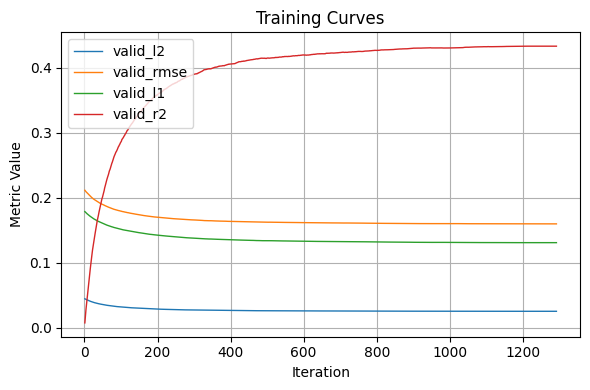

In [ ]:
from typing import Any
from ....shared.config import config

from ....shared.training.model_trainer import model_trainer
from ....shared.loaders.training_loader import training_loader
from ....shared.training.plot import PlotManager

training_cfg = config["training"]

config_selection = "top1"

current_config = training_cfg[config_selection]
model, metrics = model_trainer.train_model(
    config_dict=current_config,
    X=x,
    y=y,
)

score = float(metrics["score"])
training_time = float(metrics["training_time"])
new_config: dict[str, Any] = {
    **current_config,
    "best_score": score,
    "training_time": training_time,
}
config["training"][config_selection].update(new_config)

training_loader.save_training_model(model, additional_data=metrics)

# Print metrics like run_training did
print("Training complete. Evaluation metrics:")
for k, v in metrics.items():
    try:
        print(f"  {k}: {v:.4f}")
    except Exception:
        print("  {}: {}".format(k, v))

# Friendly post-training suggestion when no diagnostics available
if not metrics.get("curves") and not metrics.get("n_iterations"):
    print(
        "Warning: No training iterations or loss curve were recorded. Consider increasing 'epochs' or using solver='adam' with verbose=True to collect diagnostics."
    )
else:
    PlotManager.plot_loss_curve(metrics)


In [ ]:
import numpy as np
import json
from ....shared.loaders.training_loader import training_loader

# Load diagnostics (not the model itself)
data = training_loader.load_training_model_diagnostics()
if not data:
    raise FileNotFoundError("training diagnostics not found")

print("Saved model diagnostics keys:", list(data.keys()))
if "params" in data:
    raw = data["params"]
    print(f"raw data type: {type(raw)}")
    if isinstance(raw, np.ndarray) and raw.shape == ():
        raw = raw.item()
    if isinstance(raw, bytes):
        raw = raw.decode("utf-8")
    if isinstance(raw, str):
        try:
            params = json.loads(raw)
        except Exception:
            try:
                params = eval(raw)
            except Exception:
                params = raw
    else:
        params = raw
    print("  saved params:", params)


metrics_blob = data.get("metrics", data)
try:
    if isinstance(metrics_blob, np.ndarray) and metrics_blob.shape == ():
        metrics_blob = metrics_blob.item()
except Exception:
    pass
if "score_calibration" in data:
    calibration = data["score_calibration"]
    try:
        if isinstance(calibration, np.ndarray) and calibration.shape == ():
            calibration = calibration.item()
    except Exception:
        pass
    if isinstance(calibration, dict):
        print("  score_calibration keys:", list(calibration.keys()))
if (
    metrics_blob is not None
    and isinstance(metrics_blob, dict)
    and "curves" in metrics_blob
):
    lc = np.asarray(metrics_blob.get("curves", {}).get("valid", {}).get("l2", []))
    if lc.size > 0:
        print("  loss_curve (first 10):", lc[:10])
    else:
        print("  loss_curve present but empty")
elif "curves" in data:
    curves = data["curves"]
    if isinstance(curves, dict) and "valid" in curves:
        lc = np.asarray(curves["valid"].get("l2", []))
        if lc.size > 0:
            print("  loss_curve (first 10):", lc[:10])

if (
    metrics_blob is not None
    and isinstance(metrics_blob, dict)
    and "n_iterations" in metrics_blob
):
    print("  saved n_iterations:", int(metrics_blob["n_iterations"]))
elif "n_iterations" in data:
    print("  saved n_iterations:", int(data["n_iterations"]))


Saved model diagnostics keys: ['__model_b64__', 'model_type', 'training_time', 'n_iterations', 'r2', 'mae', 'rmse', 'curves', 'score', 'primary_metric']
  loss_curve (first 10): [0.04482058 0.04449577 0.04419795 0.04390536 0.04365929 0.04340706
 0.0431216  0.04290077 0.04264638 0.04246491]
  saved n_iterations: 1199


3. compare with real data

In [ ]:
x, y = load_training_data(
    retrain=False, filter_comparisons=False
)  # test with all vectors


[INF] [...er_optimizer] [...raining_data] 17:59:46 loading raw data ...
[INF] [...er_optimizer] [...raining_data] 17:59:46 raw data loaded, shape: (30732, 5913), (30732,)
[INF] [...er_optimizer] [...raining_data] 17:59:46 filtering unused features after 1000 steps...
[DBG] [...er_optimizer] [...red_features] 17:59:46  image: 
kept: 1037/1536 (67.51302083333333%)
removed: 499/1536 (32.486979166666664%)
[DBG] [...er_optimizer] [...red_features] 17:59:46  image_2: 
kept: 801/1024 (78.22265625%)
removed: 223/1024 (21.77734375%)
[DBG] [...er_optimizer] [...red_features] 17:59:46  image_3: 
kept: 927/1536 (60.3515625%)
removed: 609/1536 (39.6484375%)
[DBG] [...er_optimizer] [...red_features] 17:59:46  cfg: 
kept: 1/1 (100.0%)
removed: 0/1 (0.0%)
[DBG] [...er_optimizer] [...red_features] 17:59:46  steps: 
kept: 0/1 (0.0%)
removed: 1/1 (100.0%)
[DBG] [...er_optimizer] [...red_features] 17:59:46  clip_skip: 
kept: 1/1 (100.0%)
removed: 0/1 (0.0%)
[DBG] [...er_optimizer] [...red_features] 17:59:

Comparison metrics (sample): r2=0.7402, n=1000
Stored metrics: r2=0.4332


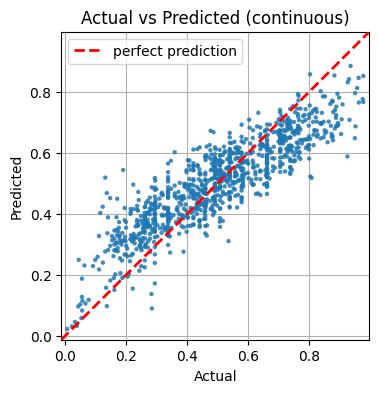

In [ ]:
from ....shared.training.plot import PlotManager

PlotManager.compare_model_vs_data(x, y, plot=True, limit=1000)
